In [1]:
# data imports -> ! run once per runtime
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow as tf
import tensorflow_datasets as tfds
import pathlib

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

# tf.keras.utils.get_file with extract=True is expected to return the path to the extracted directory.
# We will directly assign this return value to data_dir.
data_dir = tf.keras.utils.get_file(origin=dataset_url, extract=True)
data_dir = pathlib.Path(data_dir)

# The flower_photos dataset typically extracts into a top-level directory
# which itself contains another directory named 'flower_photos' that holds the category subdirectories.
# We adjust data_dir to point to this nested directory if it exists.
if (data_dir / 'flower_photos').is_dir():
    data_dir = data_dir / 'flower_photos'

# After this, data_dir should point to the directory containing 'daisy', 'dandelion', etc.

2025-12-11 19:38:45.444615: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765481925.636906      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765481925.689640      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [2]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 7.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 1.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.3 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.

In [19]:
# other necessary imports

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
from tqdm import tqdm
import time
from torchmetrics import Accuracy, F1Score

In [4]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)
print(os.listdir(data_dir))

3670
['roses', 'dandelion', 'sunflowers', 'LICENSE.txt', 'daisy', 'tulips']


641


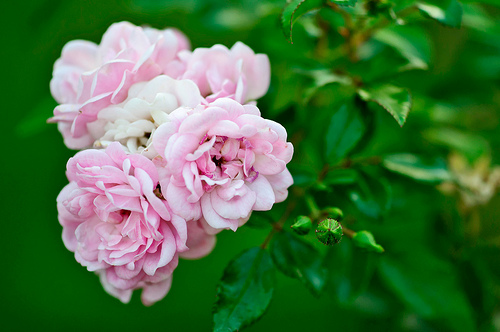

In [5]:
roses = list(data_dir.glob('roses/*'))
print(len(roses))
img = PIL.Image.open(str(roses[2]))
image = PIL.Image.open(str(roses[3]))
image = np.array(image)
image.shape
img
# => initial image shape:

In [6]:

import torchvision.transforms as transforms
from torch.utils.data import DataLoader


# Create the dataset using ImageFolder
# data_dir should be the path to your 'flower_photos' directory containing 'roses', 'daisy', etc.
full_dataset = torchvision.datasets.ImageFolder(
    root=data_dir
)

print(f"Number of images in the dataset: {len(full_dataset)}")
print(f"Classes: {full_dataset.classes}")


Number of images in the dataset: 3670
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [10]:
from sklearn.model_selection import train_test_split

targets = full_dataset.targets

train_indices, test_indices = train_test_split(
    range(len(full_dataset)),
    test_size=0.1,
    stratify=targets,
    random_state=42
)

train_indices, val_indices = train_test_split(
    train_indices,
    test_size=0.1,
    stratify=[targets[i] for i in train_indices],
    random_state=42
)

print(len(train_indices), "train samples")
print(len(val_indices), "val samples")
print(len(test_indices), "test samples")


2972 train samples
331 val samples
367 test samples


In [11]:

# WITH Augmentation
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
    transforms.RandomResizedCrop(128, scale=(0.6, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# NO Augmentation
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


In [12]:
from torch.utils.data import Dataset

class TransformSubset(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        if self.transform:
            image = self.transform(image)
        return image, label


In [13]:
train_dataset = TransformSubset(full_dataset, train_indices, train_transform)
val_dataset = TransformSubset(full_dataset, val_indices, test_transform)
test_dataset  = TransformSubset(full_dataset, test_indices, test_transform)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)


Class distribution in Training Dataset:
sunflowers: 566 samples
daisy: 513 samples
roses: 519 samples
dandelion: 727 samples
tulips: 647 samples


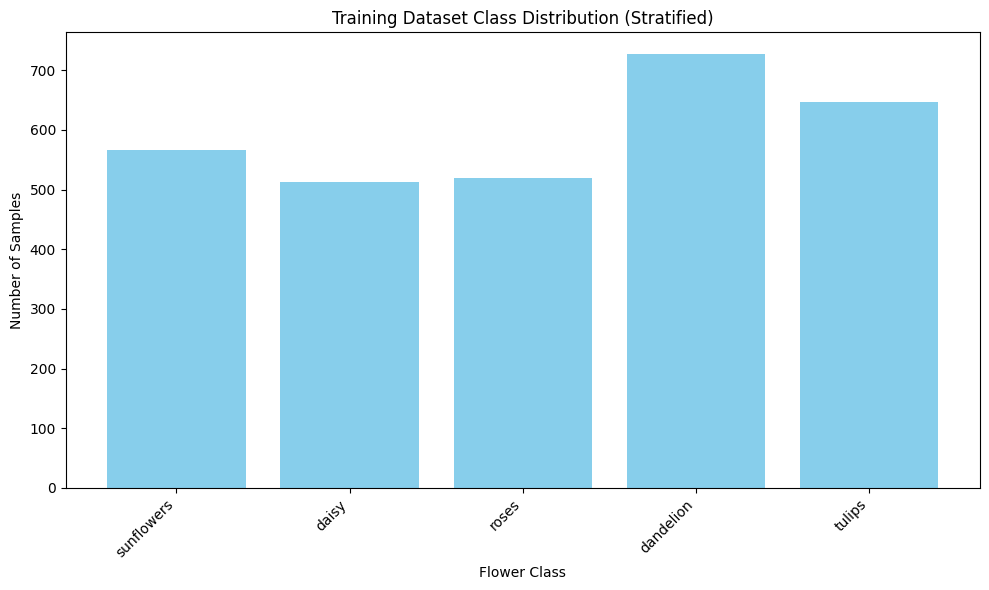

In [14]:
import collections
import matplotlib.pyplot as plt

# Get the class labels for the training dataset
train_labels = [full_dataset.targets[i] for i in train_dataset.indices]

# Count the occurrences of each class
class_counts = collections.Counter(train_labels)

# Get the class names from the original full_dataset
class_names = full_dataset.classes

# Prepare data for plotting
labels = [class_names[label] for label in class_counts.keys()]
counts = list(class_counts.values())

print("Class distribution in Training Dataset:")
for label, count in zip(labels, counts):
    print(f"{label}: {count} samples")

# Plotting the distribution
plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
plt.xlabel('Flower Class')
plt.ylabel('Number of Samples')
plt.title('Training Dataset Class Distribution (Stratified)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
class Net(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Net, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # 320 -> 160

            nn.Conv2d(32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # 160 -> 80

            nn.Conv2d(64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # 80 -> 40

            nn.Conv2d(128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2), # 40 -> 20

            nn.Conv2d(128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # 20 -> 10

            nn.Conv2d(256, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # 10 -> 5
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 2 * 2, out_features=128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
# if cuda is available use gpu else cpu

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Net(in_channels=3, num_classes=5).to(device)

In [23]:
print(model)

Net(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
 

In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

criterion.to(device)

CrossEntropyLoss()

In [16]:
# num_epochs = 400


# train_acc = Accuracy(task="multiclass", num_classes=5).to(device)
# train_f1 = F1Score(task="multiclass", num_classes=5, average="macro").to(device)

# print(f"Device: {device}")

# for epoch in range(num_epochs):
#     model.train()
#     epoch_loss = 0
#     num_batches = 0

#     # reset metrics for this epoch
#     train_acc.reset()
#     train_f1.reset()

#     print(f"\nEpoch {epoch+1}/{num_epochs}")
#     for data, targets in tqdm(train_loader, desc=f"Training Epoch {epoch+1}", leave=False):
#         data, targets = data.to(device), targets.to(device)

#         outputs = model(data)
#         loss = criterion(outputs, targets)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         # update metrics
#         preds = outputs.argmax(dim=1)
#         train_acc.update(preds, targets)
#         train_f1.update(preds, targets)

#         epoch_loss += loss.item()
#         num_batches += 1

#     avg_loss = epoch_loss / num_batches
#     epoch_acc = train_acc.compute().item()
#     epoch_f1 = train_f1.compute().item()

#     print(f"Epoch [{epoch+1}/{num_epochs}] - "
#           f"Loss: {avg_loss:.4f} | "
#           f"Train Acc: {epoch_acc:.4f} | "
#           f"Train F1: {epoch_f1:.4f}")


Device: cuda

Epoch 1/400


Epoch [1/400] - Loss: 1.5540 | Train Acc: 0.3082 | Train F1: 0.2698

Epoch 2/400


Epoch [2/400] - Loss: 1.4635 | Train Acc: 0.3524 | Train F1: 0.3365

Epoch 3/400


Epoch [3/400] - Loss: 1.3835 | Train Acc: 0.3924 | Train F1: 0.3876

Epoch 4/400


Epoch [4/400] - Loss: 1.3718 | Train Acc: 0.4163 | Train F1: 0.3960

Epoch 5/400


...

Epoch [396/400] - Loss: 0.0572 | Train Acc: 0.9837 | Train F1: 0.9833

Epoch 397/400


Epoch [397/400] - Loss: 0.0976 | Train Acc: 0.9743 | Train F1: 0.9739

Epoch 398/400


Epoch [398/400] - Loss: 0.0649 | Train Acc: 0.9827 | Train F1: 0.9825

Epoch 399/400


Epoch [399/400] - Loss: 0.0778 | Train Acc: 0.9782 | Train F1: 0.9775

Epoch 400/400


Epoch [400/400] - Loss: 0.0884 | Train Acc: 0.9740 | Train F1: 0.9738


In [25]:
num_epochs = 400

train_acc = Accuracy(task="multiclass", num_classes=5).to(device)
train_f1 = F1Score(task="multiclass", num_classes=5, average="macro").to(device)

val_acc = Accuracy(task="multiclass", num_classes=5).to(device)
val_f1  = F1Score(task="multiclass", num_classes=5, average="macro").to(device)

print(f"Device: {device}")

# Reset histories before training
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
epoch_times = []
train_f1_scores = []
val_f1_scores   = []

best_val_loss = float('inf')


for epoch in range(num_epochs):
    start_time = time.time()

    model.train()
    epoch_loss = 0
    num_batches = 0

    train_acc.reset()
    train_f1.reset()

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # -----------------------------
    # TRAINING LOOP
    # -----------------------------
    for data, targets in tqdm(train_loader, desc=f"Training Epoch {epoch+1}", leave=False):
        data, targets = data.to(device), targets.to(device)

        outputs = model(data)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        train_acc.update(preds, targets)
        train_f1.update(preds, targets)

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    epoch_acc = train_acc.compute().item()
    epoch_f1 = train_f1.compute().item()
    
    train_f1_scores.append(epoch_f1)
    train_losses.append(avg_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - "
          f"Loss: {avg_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | "
          f"Train F1: {epoch_f1:.4f}")

    # ------------------------------------------------------
    # >>> VALIDATION
    # ------------------------------------------------------
    model.eval()
    val_acc.reset()
    val_f1.reset()

    val_loss = 0.0
    val_batches = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)
            val_acc.update(preds, labels)
            val_f1.update(preds, labels)

            val_loss += loss.item()
            val_batches += 1

    avg_val_loss = val_loss / val_batches
    avg_val_acc = val_acc.compute().item()
    avg_val_f1 = val_f1.compute().item()
    val_f1_scores.append(avg_val_f1)

    val_losses.append(avg_val_loss)        # SAME length as train_losses
    val_accuracies.append(avg_val_acc)     # SAME length as train_accuracies

    print(f"Validation - Loss: {avg_val_loss:.4f} | Acc: {avg_val_acc:.4f} | F1: {avg_val_f1:.4f}")

    # save best model
    if avg_val_loss < best_val_loss:
        torch.save(model.state_dict(), "best_model.pth")
        best_val_loss = avg_val_loss

    # timing
    epoch_times.append(time.time() - start_time)    


Device: cuda

Epoch 1/400


Epoch [1/400] - Loss: 1.6277 | Train Acc: 0.2598 | Train F1: 0.2364


Validation - Loss: 1.5343 | Acc: 0.2991 | F1: 0.1717

Epoch 2/400


Epoch [2/400] - Loss: 1.5718 | Train Acc: 0.2789 | Train F1: 0.2467


Validation - Loss: 1.5274 | Acc: 0.2810 | F1: 0.1691

Epoch 3/400


...

Validation - Loss: 0.3814 | Acc: 0.8912 | F1: 0.8890

Epoch 399/400


Epoch [399/400] - Loss: 0.0782 | Train Acc: 0.9754 | Train F1: 0.9753


Validation - Loss: 0.3054 | Acc: 0.9063 | F1: 0.9053

Epoch 400/400


Epoch [400/400] - Loss: 0.0570 | Train Acc: 0.9818 | Train F1: 0.9817


Validation - Loss: 0.3288 | Acc: 0.9063 | F1: 0.9058


In [26]:
print("\nFinal Evaluation:")
model.eval()

acc_metric = Accuracy(task="multiclass", num_classes=5).to(device)
f1_metric = F1Score(task="multiclass", num_classes=5, average='macro').to(device)


with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Final Evaluation"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        acc_metric.update(preds, labels)
        f1_metric.update(preds, labels)

final_accuracy = acc_metric.compute()
final_macro_f1 = f1_metric.compute()

print(f"Final Test Accuracy: {final_accuracy:.4f}")
print(f"Final Test Macro F1 Score: {final_macro_f1:.4f}")



Final Evaluation:


Final Evaluation: 100%|██████████| 6/6 [00:00<00:00,  7.17it/s]

Final Test Accuracy: 0.9292
Final Test Macro F1 Score: 0.9274


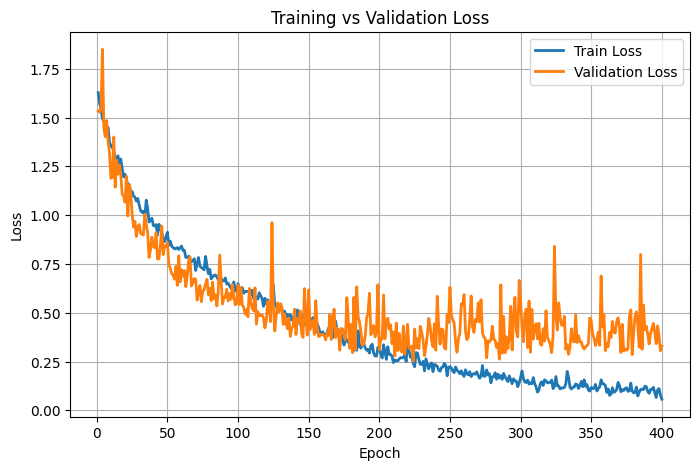

In [33]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, label="Train Loss", linewidth=2)
plt.plot(epochs, val_losses, label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("v4_loss.png", dpi=300)
plt.show()


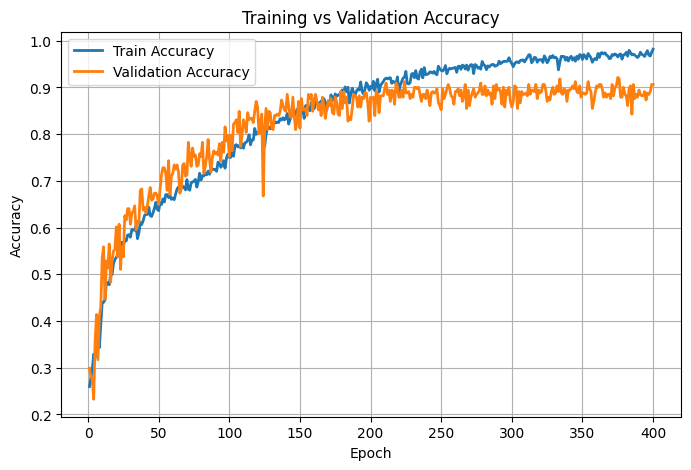

In [34]:
plt.figure(figsize=(8,5))
plt.plot(epochs, train_accuracies, label="Train Accuracy", linewidth=2)
plt.plot(epochs, val_accuracies, label="Validation Accuracy", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("v4_accuracy.png", dpi=300)
plt.show()


In [ ]:
plt.figure(figsize=(8,5))
plt.plot(epochs, train_f1_scores, label="Train F1", linewidth=2)
plt.plot(epochs, val_f1_scores,   label="Validation F1", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Training vs Validation F1 Score")
plt.legend()
plt.grid(True)
plt.show()


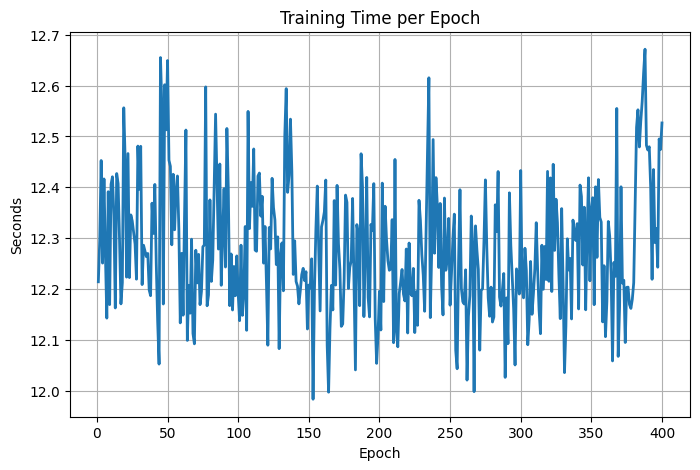

In [37]:
# training time per epoch
epochs = range(1, len(epoch_times) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, epoch_times, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Seconds")
plt.title("Training Time per Epoch")
plt.grid(True)

plt.savefig("epoch_times.png", dpi=300)
plt.show()


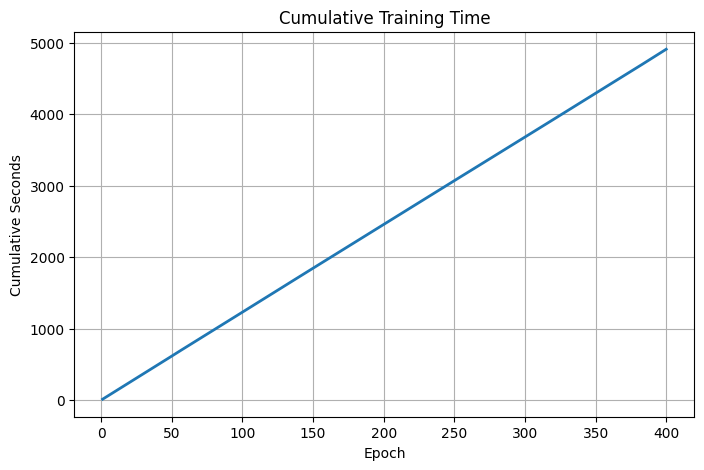

In [39]:
# cummulative training time


cumulative_time = np.cumsum(epoch_times)

plt.figure(figsize=(8,5))
plt.plot(epochs, cumulative_time, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Cumulative Seconds")
plt.title("Cumulative Training Time")
plt.grid(True)

plt.savefig("cumulative_training_time.png", dpi=300)
plt.show()


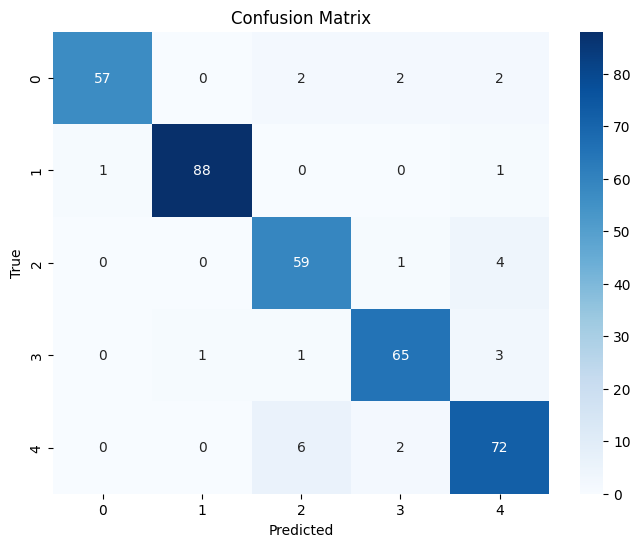

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()


In [31]:
torch.save(model.state_dict(), "best_model4.pth")

# to load this model later
# model = Net(in_channels=3, num_classes=5)
# model.load_state_dict(torch.load("best_model.pth"))
# model.eval()

In [32]:
import json

results = {
    "test_accuracy": float(final_accuracy),
    "test_macro_f1": float(final_macro_f1),
    "train_accuracy": float(epoch_acc),
    "train_macro_f1": float(epoch_f1),
    "model_architecture": "Custom CNN 32-64-128-256 Conv Blocks",
    "input_size": "128x128",
    "date": "2025-02-08"
}

with open("results4.json", "w") as f:
    json.dump(results, f, indent=4)
